# RAPID-MFA-10b: Material substitution over time

## Descriptions
This module implements material substitution gradually over time. This is illustrated with the example of cars. Rather than a sudden change from one year to the next, like in `RAPID-MFA-10a: Immediate material substitution`, the new material intensities are now only reached after 10 years of transition time. In this example we assume a linear change, but this can, and should, be freely modified and fit to your specific case. Note that in this example the car type stays the same, but its material composition changes, while in `RAPID-MFA-11: Type substitution` the material composition of each car type is stable, but the share of car types in the inflow changes.

# NOTE for __Tomer__:
If you have time, you thought about adding the system figure like in RAPID-MFA-9, but here visualizing the two material layers.

### Relations with other RAPID-MFA codes
- This model builds on the basic `RAPID-MFA-2: The stock driven model`, which is used as the core building block for all other RAPID-MFA codes that use the stock driven model.
- `RAPID-MFA-5: Different lifetime functions`: The code below uses the Weibull lifetime distribution as introduced in module 5. The shape and scale parameters were adapted to the literature source.
- `RAPID-MFA-5: Type substitution`: In this module the car types stay the same but their MI changes, in the type substitution module the car type, which has a different MI, is changed. While they are not the same they can be related, so check which one fits your specific case.

### Relations with other RAPID-MFA codes
- This model builds on `RAPID-MFA-9: Switching from products/services to materials with changing material composition`, which is used as the core building block.
- `RAPID-MFA-5: Different lifetime functions`: The code below uses the Weibull lifetime distribution as introduced in module 5. The shape and scale parameters were adapted to the literature source.
- `RAPID-MFA-11: Type substitution`: In this module the car types stay the same but their MI changes, in the type substitution module the car type, which has a different MI, is changed. While they are not the same they can be related, so verify which one fits your specific case.

### Data sources
__Stocks:__ From https://doi.org/10.3390/resources7010009

__Survival curve:__ Weibull distribution, $shape=2.4$, $scale=16.9$, e.g. using `scipy.stats.weibull_min.sf(range(0, len(input_data)), c = 2.428914875, loc = 0, scale = 16.93851375)` Data from https://doi.org/10.3390/resources7010009

__Material intensity:__ In kg/vehicle from Fishman, T., Myers, R.J., Rios, O., Graedel, T.E., 2018. Implications of Emerging Vehicle Technologies on Rare Earth Supply and Demand in the United States.
 Resources 7 (https://doi.org/10.3390/resources7010009)

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__.

## 1. Load libraries

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Define example input data

<Axes: xlabel='Year', ylabel='kg/vehicle'>

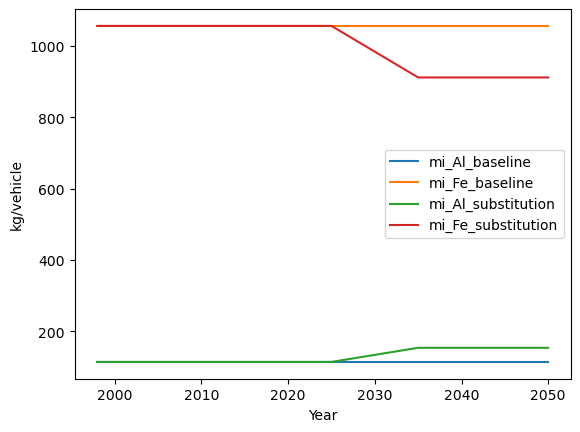

In [2]:
# timeframe, stock data represents stock of cars
input_data = pd.Series([0, 17, 9367, 29639, 65611, 112994, 196655, 405237, 655629, 1002834, 1307203,
                        1584131, 1836332, 2092277, 2537144, 3074043, 3567853, 4207156, 4945879, 5797925,
                        6778277, 7902746, 9187646, 10649295, 12303394, 14164318, 16244276, 18552466,
                        21094228, 23870337, 26876417, 30102657, 33533764, 37149274, 40924083, 44829315, 48833234,
                        52902345, 57002464, 61099726, 65161509, 69157195, 73058775, 76841335, 80483330, 83966772,
                        87277263, 90403948, 93339367, 96079253, 98622261, 100969690, 103125124],
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
                                2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                                2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
                                2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
                                2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050])

# creating the Weibull distribution curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
shape = 2.428914875
scale = 16.93851375
# create the surivival curve
survival_curve = scipy.stats.weibull_min.sf(ages, c = shape, loc = 0, scale = scale) #loc is not defined in this scenario, so we leave it at 0

# defining the material intensities
material_intensities_dict = {
    'mi_Al_baseline': 114.51,
    'mi_Fe_baseline': 1056.21065,
    'mi_Al_substitution': 154.07340,
    'mi_Fe_substitution': 911.80425}  # in grams per vehicle, to match the units of material_intensities


# create a dataframe that holds the MI data
material_intensities = pd.DataFrame(np.nan,
                                    index = input_data.index,
                                    columns = material_intensities_dict.keys()
                                    )

material_intensities['mi_Al_baseline'] = material_intensities_dict['mi_Al_baseline']
material_intensities['mi_Fe_baseline'] = material_intensities_dict['mi_Fe_baseline']

# define the transition start year and the transition end year
transition_start = 2025
transition_end = 2035

# from the start in 1980 until 2024 the old MI applies
material_intensities.loc[:(transition_start-1), 'mi_Al_substitution'] = material_intensities_dict['mi_Al_baseline']
# from 2025 until 2035 is the transition period
material_intensities.loc[transition_start:transition_end, 'mi_Al_substitution'] = np.interp(np.arange(transition_start, transition_end+1,1), [transition_start, transition_end], [material_intensities_dict['mi_Al_baseline'], material_intensities_dict['mi_Al_substitution']])
# from 2036 onwards the new MI applies
material_intensities.loc[(transition_end+1):, 'mi_Al_substitution'] = material_intensities_dict['mi_Al_substitution']

# from the start in 1980 until 2024 the old MI applies
material_intensities.loc[:(transition_start-1), 'mi_Fe_substitution'] = material_intensities_dict['mi_Fe_baseline']
# from 2025 until 2035 is the transition period
material_intensities.loc[transition_start:transition_end, 'mi_Fe_substitution'] = np.interp(np.arange(transition_start, transition_end+1,1), [transition_start, transition_end], [material_intensities_dict['mi_Fe_baseline'], material_intensities_dict['mi_Fe_substitution']])
# from 2036 onwards the new MI applies
material_intensities.loc[(transition_end+1):, 'mi_Fe_substitution'] = material_intensities_dict['mi_Fe_substitution']


material_intensities.plot(ylabel='kg/vehicle', xlabel='Year')

## 3. Set up the MFA system

In [3]:
# Define the units of the system, with separate units for the products layer (vehicles in number of units) and the materials layer (in mass)
units = {'time_interval': 'year', 
         'product_flows': 'vehicles/year', 
         'product_stocks': 'vehicles',
         'material_flows': 'kg/year',
         'material_stocks': 'kg',
         'material_intensities': 'kg/vehicle'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

time_interval = 1

cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required

## 4. Create the baseline model on the product layer (vehicles)

We start by creating the surivival curves matrix. From that we can calculate the cohort survival matrix, providing us with number of vehicles in stock per timestep and cohort. We then calculate the inflows, stock changes, and outflows. The heatmap visualizes the survival of each cohort over time.

<Axes: ylabel='vehicles/year'>

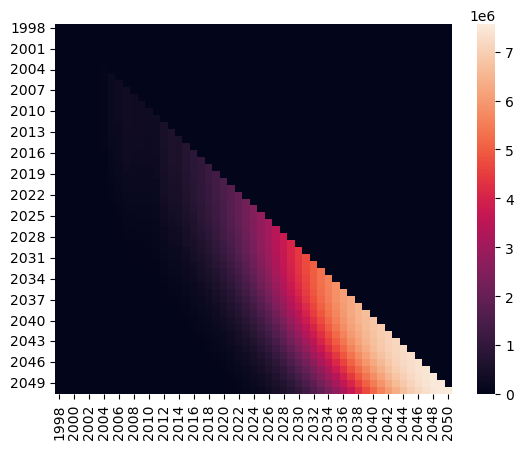

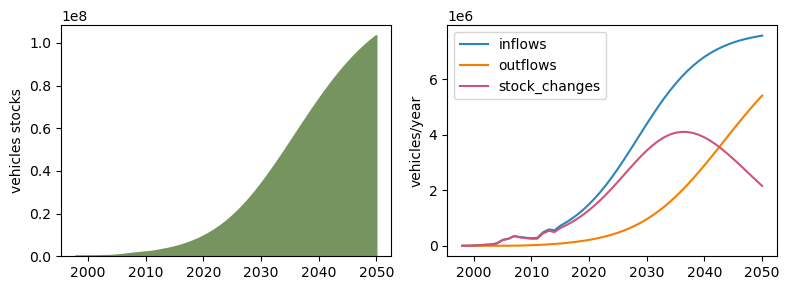

In [4]:
# create the survival curves matrix for the baseline scenario
survival_curves_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # create an initial survival curves matrix filled with zeros
for cohort in cohorts:
    survival_curves_matrix_baseline.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]  # at each iteration, fill a shifted survival curve (cut at its end) into the next column of the survival curves matrix, from the diagonal downwards. Leave the upper part with zeros.
    

# create an empty dataframe to hold the results of the MFA for the product (vehicles) layer
mfa_system_baseline_vehicles = pd.DataFrame(index = timeframes, columns = ['stocks', 'inflows', 'outflows', 'stock_changes'])
mfa_system_baseline_vehicles['stocks'] = input_data  # the stocks in units of vehicles are already known from the input data

# create the cohorts survival matrix for vehicles of the baseline scenario
cohorts_survival_matrix_baseline_vehicles = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # initialize the cohort_survival_matrix filled with zeros

# the stock-driven model for vehicles
for cohort in cohorts:
    mfa_system_baseline_vehicles.loc[cohort, 'inflows'] = (mfa_system_baseline_vehicles.loc[cohort, 'stocks'] - cohorts_survival_matrix_baseline_vehicles.loc[cohort, : cohort - 1].sum()
                                                           ) / survival_curves_matrix_baseline.loc[cohort, cohort]  # calculate the inflow of the time-th year
    cohorts_survival_matrix_baseline_vehicles.loc[:, cohort] = survival_curves_matrix_baseline.loc[:, cohort] * mfa_system_baseline_vehicles.loc[cohort, 'inflows']  # now that the time-th inflow is known, scale the shifted survival curve with this inflow to add a new cohort's survival to the cohorts survival matrix

# and visualize the cohort_survival_matrix matrix with a heatmap
sns.heatmap(cohorts_survival_matrix_baseline_vehicles, annot=False)

mfa_system_baseline_vehicles["stock_changes"] = np.diff(mfa_system_baseline_vehicles["stocks"], prepend=0)  # stock_changes is the difference between two timeframes. Prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe. 
mfa_system_baseline_vehicles["outflows"] = mfa_system_baseline_vehicles["inflows"] - mfa_system_baseline_vehicles["stock_changes"]  # Calculate outflows using mass balance

# visualize the results of the MFA for vehicles
mfa_system_baseline_vehicles_fig, mfa_system_baseline_vehicles_ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), tight_layout=True)
mfa_system_baseline_vehicles['stocks'].plot(ylabel=units['product_stocks']+" stocks", 
                                            kind="area", color='#759460', 
                                            ax=mfa_system_baseline_vehicles_ax[0])  # visualize the stocks to learn what their trends are like and to make sure they look reasonable.


mfa_system_baseline_vehicles[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units['product_flows'], 
                                                                            color=["#2985BD", "#F67E00", "#D15278"],
                                                                            ax=mfa_system_baseline_vehicles_ax[1])

## 5. Convert inflows from products to materials
We then convert the number of vehicles to the equivalent mass of steel and aluminum using the flow driven model. The inputs for the flow-driven model are the calculated inflows from the baseline stock-driven model in step 4 using the material intensities time series:

$
\textcolor{#2A8596}{\text{material inflows}(t)[mass]} = \textcolor{#C58D01}{\text{product inflows}(t)[units]} \times \textcolor{#C32D2E}{\text{material intensities}(t)[\frac{mass}{unit}]}
$

In [5]:
#Calculate the MFA for the baseline

# create an empty dataframe to hold the results of the MFA for the materials layer
# note the multiindex columns, which has two levels: material and timeseries (of each material). 
# with multiindex, we can have the inflows, outflows, stock_changes for both steel and aluminum in the same dataframe
mfa_system_baseline_materials = pd.DataFrame(index = timeframes, 
                                             columns = pd.MultiIndex.from_product([['aluminum', 'steel'], mfa_system_baseline_vehicles.columns], 
                                                                                  names=['material', 'timeseries']))

# Calculate the MFA for aluminum using the flow driven model
# inflows from the vehicles layer times the aluminum material intensity
mfa_system_baseline_materials[('aluminum', 'inflows')] = mfa_system_baseline_vehicles['inflows'] * material_intensities['mi_Al_baseline']
# the flow driven model for aluminum
cohorts_survival_matrix_baseline_aluminum = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # initialize the cohort_survival_matrix filled with zeros
for cohort in cohorts:
    cohorts_survival_matrix_baseline_aluminum.loc[:, cohort] = survival_curves_matrix_baseline.loc[:, cohort] * mfa_system_baseline_materials[('aluminum', 'inflows')].loc[cohort]
mfa_system_baseline_materials[('aluminum', 'stocks')] = cohorts_survival_matrix_baseline_aluminum.sum(axis='columns')  # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
mfa_system_baseline_materials[('aluminum', 'stock_changes')] = np.diff(mfa_system_baseline_materials[('aluminum', 'stocks')], prepend=0)  # stock_changes is the difference between two timeframes. Prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
mfa_system_baseline_materials[('aluminum', 'outflows')] = mfa_system_baseline_materials[('aluminum', 'inflows')] - mfa_system_baseline_materials[('aluminum', 'stock_changes')]  # Calculate outflows using mass balance

# calculate the MFA for steel using the flow driven model
# inflows from the vehicles layer times the steel material intensity
mfa_system_baseline_materials[('steel', 'inflows')] = mfa_system_baseline_vehicles['inflows'] * material_intensities['mi_Fe_baseline']
# the flow driven model for steel
cohorts_survival_matrix_baseline_steel = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # initialize the cohort_survival_matrix filled with zeros
for cohort in cohorts:
    cohorts_survival_matrix_baseline_steel.loc[:, cohort] = survival_curves_matrix_baseline.loc[:, cohort] * mfa_system_baseline_materials[('steel', 'inflows')].loc[cohort]
mfa_system_baseline_materials[('steel', 'stocks')] = cohorts_survival_matrix_baseline_steel.sum(axis='columns')  # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
mfa_system_baseline_materials[('steel', 'stock_changes')] = np.diff(mfa_system_baseline_materials[('steel', 'stocks')], prepend=0)  # stock_changes is the difference between two timeframes. Prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
mfa_system_baseline_materials[('steel', 'outflows')] = mfa_system_baseline_materials[('steel', 'inflows')] - mfa_system_baseline_materials[('steel', 'stock_changes')]  # Calculate outflows using mass balance

Note that we could have used a <<for material in ['aluminum', 'steel']>> loop to avoid repeating the same code for both materials, but we wrote it out separately for clarity.


## 6. Scenario B

A new alloy is gradually introduced to the market. In 2025, 1% of new cars have the new MIs, growing linearly to 50% of new cars sold in 2050. The rest have the original MIs. For clarity and simplicity we treat the cars with the old MIs and those with new MIs as two separate products, each with their own flow-driven dynamic MFA that will get converted to steel and aluminum with their appropriate MIs. For that we split the total inflows of vehicles into the two separate types. Then we can calculate two separate dMFAs that together represent the complete system.

In [6]:
# copy over the vehicles baseline dataframe
mfa_system_scenario1B_vehicles = mfa_system_baseline_vehicles.copy()  # the stocks and flows of vehicles should be identical to the baseline scenario but it's good practice to have a unique dataframe per scenario

# create an empty multiindex dataframe to hold the results of the MFA for the materials layer
mfa_system_scenario1B_materials = pd.DataFrame(index = timeframes,
                                               columns = pd.MultiIndex.from_product([['aluminum', 'steel'], mfa_system_baseline_vehicles.columns], 
                                                                                    names=['material', 'timeseries']))

# calculate the MFA for aluminum using the flow driven model
# inflows from the vehicles layer times the aluminum material intensity
mfa_system_scenario1B_materials[('aluminum', 'inflows')] = mfa_system_scenario1B_vehicles['inflows'] * material_intensities['mi_Al_substitution']
# the flow driven model for aluminum
cohorts_survival_matrix_scenario1B_aluminum = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # initialize the cohort_survival_matrix filled with zeros
for cohort in cohorts:
    cohorts_survival_matrix_scenario1B_aluminum.loc[:, cohort] = survival_curves_matrix_baseline.loc[:, cohort] * mfa_system_scenario1B_materials[('aluminum', 'inflows')].loc[cohort]
mfa_system_scenario1B_materials[('aluminum', 'stocks')] = cohorts_survival_matrix_scenario1B_aluminum.sum(axis='columns')  # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
mfa_system_scenario1B_materials[('aluminum', 'stock_changes')] = np.diff(mfa_system_scenario1B_materials[('aluminum', 'stocks')], prepend=0)  # stock_changes is the difference between two timeframes. Prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
mfa_system_scenario1B_materials[('aluminum', 'outflows')] = mfa_system_scenario1B_materials[('aluminum', 'inflows')] - mfa_system_scenario1B_materials[('aluminum', 'stock_changes')]  # Calculate outflows using mass balance

# calculate the MFA for steel using the flow driven model
# inflows from the vehicles layer times the steel material intensity
mfa_system_scenario1B_materials[('steel', 'inflows')] = mfa_system_scenario1B_vehicles['inflows'] * material_intensities['mi_Fe_substitution']
# the flow driven model for steel
cohorts_survival_matrix_scenario1B_steel = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # initialize the cohort_survival_matrix filled with zeros
for cohort in cohorts:
    cohorts_survival_matrix_scenario1B_steel.loc[:, cohort] = survival_curves_matrix_baseline.loc[:, cohort] * mfa_system_scenario1B_materials[('steel', 'inflows')].loc[cohort]
mfa_system_scenario1B_materials[('steel', 'stocks')] = cohorts_survival_matrix_scenario1B_steel.sum(axis='columns')  # the stocks are the sum of the surviving cohorts, which is the sum of cohorts survival matrix row by row.
mfa_system_scenario1B_materials[('steel', 'stock_changes')] = np.diff(mfa_system_scenario1B_materials[('steel', 'stocks')], prepend=0)  # stock_changes is the difference between two timeframes. Prepend=0 covers the convention that stock_change is the difference between current timeframe and previous timeframe.
mfa_system_scenario1B_materials[('steel', 'outflows')] = mfa_system_scenario1B_materials[('steel', 'inflows')] - mfa_system_scenario1B_materials[('steel', 'stock_changes')]  # Calculate outflows using mass balance

## 7. Compare MFA results

<Axes: title={'center': 'Scenario B'}, ylabel='kg/year'>

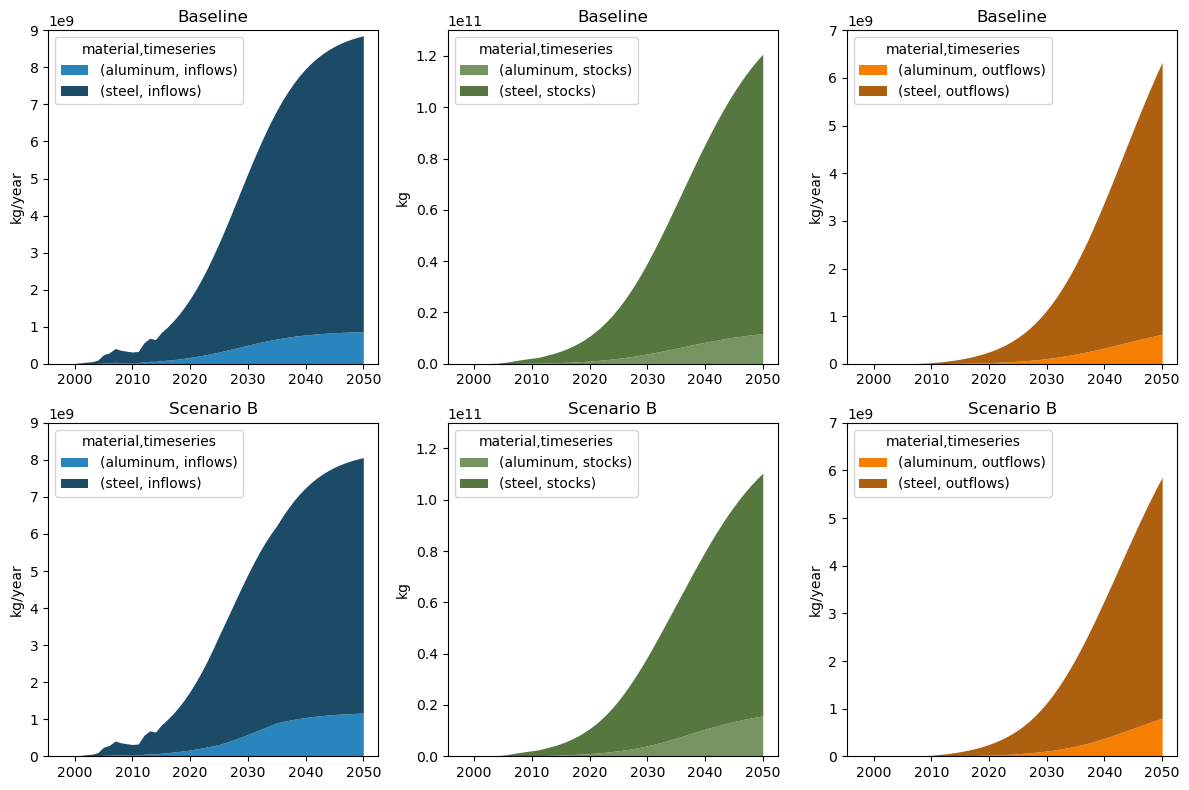

In [7]:
# visualize the inflows, outflows, and stocks results for the baseline and scenario B
results_fig, results_ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), tight_layout=True)
# plotting the baseline results
mfa_system_baseline_materials.loc[:, (slice(None), 'inflows')].plot(ylabel=units['material_flows'], 
                                                                                   kind='area', ylim=(0, 9e9),
                                                                                   color=["#2985BD", "#1C4B68", "#62B5E9", "#517388"],
                                                                                   ax=results_ax[0, 0],
                                                                                   linewidth = 0,
                                                                                   title = 'Baseline'
                                                                                   )
mfa_system_baseline_materials.loc[:, (slice(None), 'stocks')].plot(ylabel=units['material_stocks'], 
                                                                                  kind='area', ylim=(0, 1.3e11),
                                                                                  color=["#759460", "#567840", "#A9D18E", "#7B9740"],
                                                                                  ax=results_ax[0, 1],
                                                                                  linewidth = 0,
                                                                                  title = 'Baseline'
                                                                                  )
mfa_system_baseline_materials.loc[:, (slice(None), 'outflows')].plot(ylabel=units['material_flows'], 
                                                                                    kind='area', ylim=(0, 7e9),
                                                                                    color=["#F67E00", "#AC6010", "#F9A16B", "#B06A2E"],
                                                                                    ax=results_ax[0, 2],
                                                                                    linewidth = 0,
                                                                                    title = 'Baseline'
                                                                                    )
# plotting the scenario B results
mfa_system_scenario1B_materials.loc[:, (slice(None), 'inflows')].plot(ylabel=units['material_flows'], 
                                                                                   kind='area', ylim=(0, 9e9),
                                                                                   color=["#2985BD", "#1C4B68", "#62B5E9", "#517388"],
                                                                                   ax=results_ax[1, 0],
                                                                                   linewidth = 0,
                                                                                   title = 'Scenario B'
                                                                                   )
mfa_system_scenario1B_materials.loc[:, (slice(None), 'stocks')].plot(ylabel=units['material_stocks'], 
                                                                                  kind='area', ylim=(0, 1.3e11),
                                                                                  color=["#759460", "#567840", "#A9D18E", "#7B9740"],
                                                                                  ax=results_ax[1, 1],
                                                                                  linewidth = 0,
                                                                                  title = 'Scenario B'
                                                                                  )
mfa_system_scenario1B_materials.loc[:, (slice(None), 'outflows')].plot(ylabel=units['material_flows'], 
                                                                                    kind='area', ylim=(0, 7e9),
                                                                                    color=["#F67E00", "#AC6010", "#F9A16B", "#B06A2E"],
                                                                                    ax=results_ax[1, 2],
                                                                                    linewidth = 0,
                                                                                    title = 'Scenario B'
                                                                                    )



### Material stock productivity

$\text{Material stock productivity} = \frac{\text{service provision}}{\text{material stock}}$

Text(0.5, 0, 'Year')

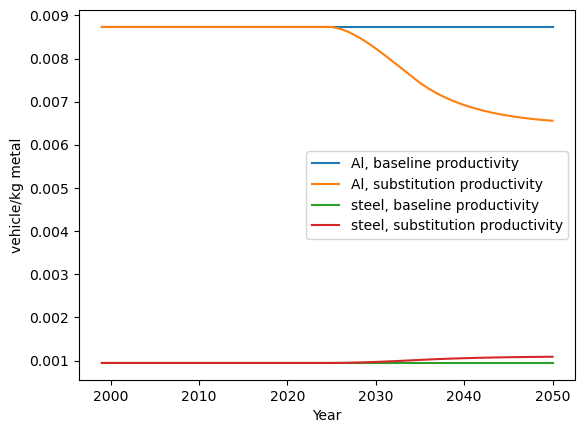

In [8]:
# for aluminum
(mfa_system_baseline_vehicles['stocks']/mfa_system_baseline_materials[('aluminum', 'stocks')]).plot(label = 'Al, baseline productivity')
(mfa_system_scenario1B_vehicles['stocks']/mfa_system_scenario1B_materials[('aluminum', 'stocks')]).plot(label = 'Al, substitution productivity')

# for steel
(mfa_system_baseline_vehicles['stocks']/mfa_system_baseline_materials[('steel', 'stocks')]).plot(label = 'steel, baseline productivity')
(mfa_system_scenario1B_vehicles['stocks']/mfa_system_scenario1B_materials[('steel', 'stocks')]).plot(label = 'steel, substitution productivity')
plt.legend()
plt.ylabel('vehicle/kg metal')
plt.xlabel('Year')